# Performance by supervision mode — Triage game
**Only validated participants (`Valido == 'si'`) are included.**

Test-phase analysis only. Three outcomes:
- **Total score** (max 30)
- **Selection score** (max 15)
- **Destination score** (max 15)


In [1]:
import sys
print(sys.executable)

/Users/MartiLlairo/opt/anaconda3/envs/tfm/bin/python


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import shapiro, probplot
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")


%matplotlib inline
plt.rcParams["figure.dpi"] = 130


## Configuration

In [3]:
# ── Update this path to point to your CSV ────────────────────────────────────
DATA_PATH = "triage_data_last_v2.csv"


## Load and filter data

In [ ]:
df_raw = pd.read_csv(DATA_PATH, sep=",")
participantes = [
    'P044', 'P043', 'P042', 'P040', 'P038', 'P036', 'P035',
    'P026', 'P025', 'P022', 'P019', 'P018', 'P017', 'P016',
    'P015', 'P012', 'P010', 'P050', 'P059'
]

df = df_raw[df_raw['participant_id'].isin(participantes)].copy()

n_guided = (df["mode"] == "guided").sum()
n_error  = (df["mode"] == "error_based").sum()

print(f"Total rows in file : {len(df_raw)}")
print(f"Valid participants  : {len(df)}")
print(f"  Guided            : {n_guided}")
print(f"  Error-based       : {n_error}")

# Filter invalid data

# ── P044: misclick on test G1 destinations ────────────────────────────────────

# Set the erroneous score to NaN — excluded from calculations, participant kept
print("P044 test_g1_destinations_score before:", 
      df.loc[df["participant_id"] == "P044", "test_g1_destinations_score"].values)

df.loc[df["participant_id"] == "P044", "test_g1_destinations_score"] = np.nan

# Recompute test_dest_total and test_total for P044 since they depended on G1
# test_dest_total = g1 + g2 + g3 destinations
dest_cols = ["test_g1_destinations_score",
             "test_g2_destinations_score",
             "test_g3_destinations_score"]
df["test_dest_total"] = df[dest_cols].sum(axis=1, min_count=1)  # NaN if all NaN
df["test_total"]      = df["test_sel_total"] + df["test_dest_total"]

print("P044 test_g1_destinations_score after: ",
      df.loc[df["participant_id"] == "P044", "test_g1_destinations_score"].values)
print("P044 test_dest_total after:            ",
      df.loc[df["participant_id"] == "P044", "test_dest_total"].values)
print("P044 test_total after:                 ",
      df.loc[df["participant_id"] == "P044", "test_total"].values)

# ── P026: NASA default responses — exclude from all NASA analyses ─────────────
NASA_EXCLUDE = ["P026"]

df_nasa = df[~df["participant_id"].isin(NASA_EXCLUDE)].copy()

print(f"\nMain df (all analyses):  n = {len(df)}")
print(f"NASA df (NASA analyses): n = {len(df_nasa)}")
print(f"  Guided      : {(df_nasa['mode']=='guided').sum()}")
print(f"  Error-based : {(df_nasa['mode']=='error_based').sum()}")
print(f"  Excluded    : {NASA_EXCLUDE} (all-default NASA responses)")

# ── Create Kendall tau variables ──────────────────────────────────────────────
df["test_kendall_tau_total"] = (df["test_g1_kendall_tau"] +
                                df["test_g2_kendall_tau"] +
                                df["test_g3_kendall_tau"])



# ── Shared config ─────────────────────────────────────────────────────────────
COLORS = {"guided": "#7F77DD", "error_based": "#1D9E75"}
MODES  = ["guided", "error_based"]
XLABELS = {"guided": "Guided", "error_based": "Error-based"}
X = {"guided": 0.25, "error_based": 0.75}

rng = np.random.default_rng(42)


Total rows in file : 59
Valid participants  : 19
  Guided            : 10
  Error-based       : 9
P044 test_g1_destinations_score before: [0.]
P044 test_g1_destinations_score after:  [nan]
P044 test_dest_total after:             [10.]
P044 test_total after:                  [23.]

Main df (all analyses):  n = 19
NASA df (NASA analyses): n = 18
  Guided      : 10
  Error-based : 8
  Excluded    : ['P026'] (all-default NASA responses)
P044 group scores:
    test_g1_score  test_g2_score  test_g3_score  test_score_mean
15            NaN           10.0           10.0             10.0

All participants — test_score_mean vs test_total:
participant_id        mode  test_g1_score  test_g2_score  test_g3_score  test_score_mean  test_total
          P059 error_based            8.0            5.0            5.0         6.000000        18.0
          P050      guided            9.0            9.0            8.0         8.666667        26.0
          P044      guided            NaN           10.0    

## 1. Performance by supervision mode

###  1.0. Normality checks

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 2. NORMALITY CHECKS — OUTCOMES (retroactive justification for Mann-Whitney)
# ════════════════════════════════════════════════════════════════════════════
RETRO     = {
    "test_score_mean":        "Mean score per group (0–10)",
    "test_kendall_tau_total": "Kendall τ total",
}


print("=" * 65)
print("NORMALITY CHECKS — OUTCOMES (per supervision mode group)")
print("Retroactive justification for Mann-Whitney test choice.")
print("=" * 65)

fig, axes = plt.subplots(len(RETRO), 2, figsize=(10, 4 * len(RETRO)))
fig.patch.set_facecolor("white")

for row_idx, (col, label) in enumerate(RETRO.items()):
    for col_idx, mode in enumerate(MODES):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor("white")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#CCCCCC")

        vals = df.loc[df["mode"] == mode, col].dropna()

        (osm, osr), (slope, intercept, r) = probplot(vals, dist="norm")
        ax.plot(osm, osr, "o", color=COLORS[mode], alpha=0.85,
                markersize=7, markeredgecolor="white", markeredgewidth=0.5)
        ax.plot(osm, slope * np.array(osm) + intercept,
                color="#AAAAAA", lw=1.5, linestyle="--")

        W, p = shapiro(vals)
        ax.set_title(
            f"{label}\n{mode.replace('_','-').title()}  "
            f"(n={len(vals)})  |  W={W:.3f}, p={p:.3f}",
            fontsize=9, color="#333333", pad=6
        )
        ax.set_xlabel("Theoretical quantiles", fontsize=8, color="#555555")
        ax.set_ylabel("Sample quantiles",      fontsize=8, color="#555555")
        ax.grid(color="#EEEEEE", linewidth=0.8, zorder=0)

        interp = "→ fail to reject normality" if p > .05 else "→ REJECT normality"
        print(f"  {label} | {mode:12s} | n={len(vals)} | "
              f"W={W:.3f}, p={p:.3f}  {interp}")
    print()

fig.suptitle("Q-Q plots — outcomes by supervision mode\n"
             "(retroactive normality check for Mann-Whitney justification)",
             fontsize=12, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("qq_outcomes.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

### 3.1. Aggregate Scores

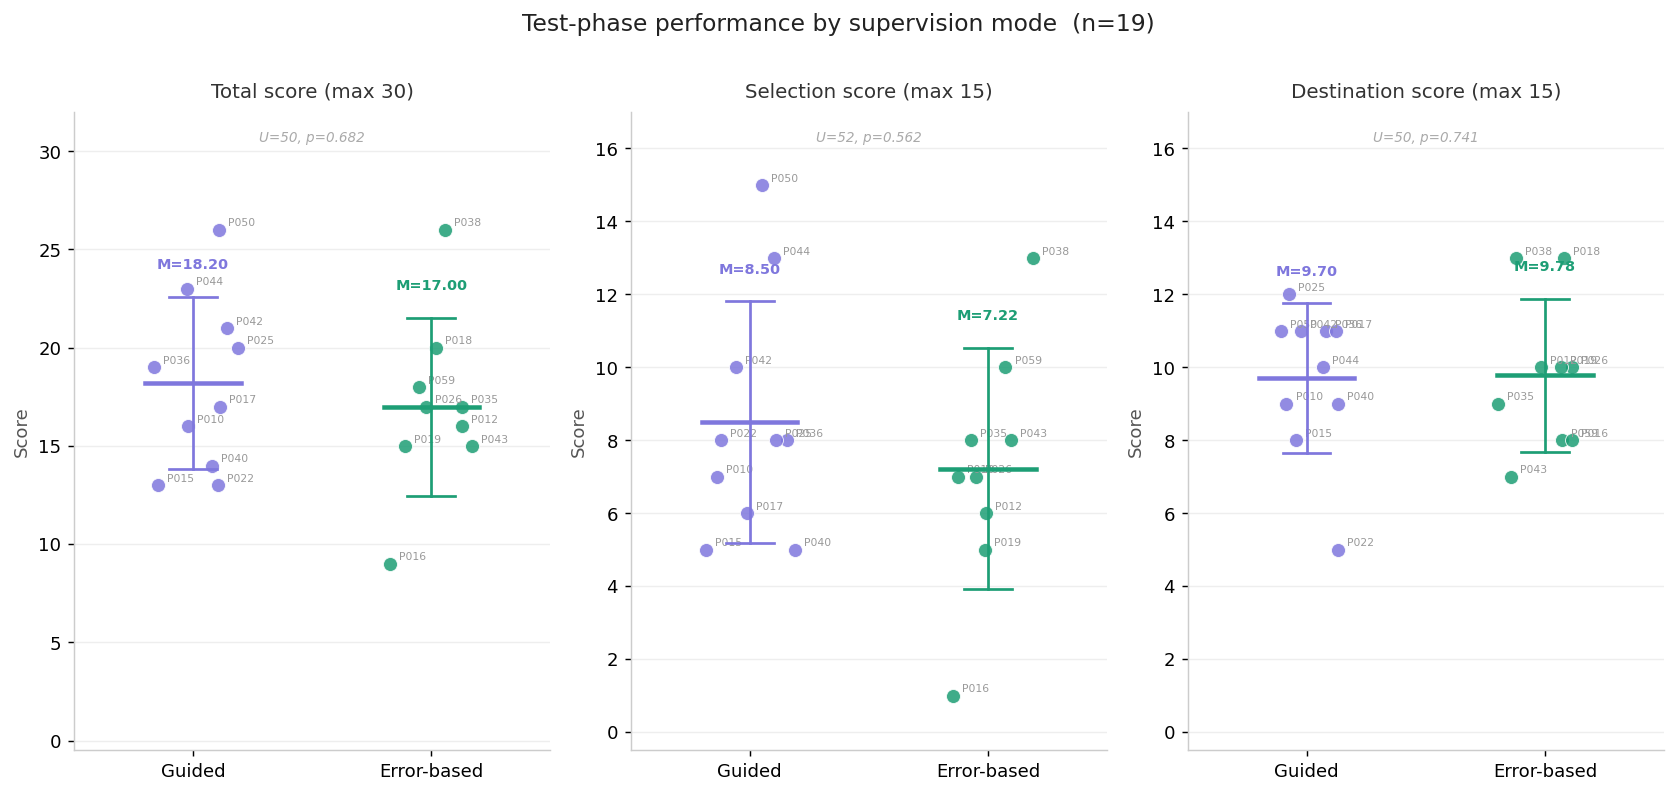

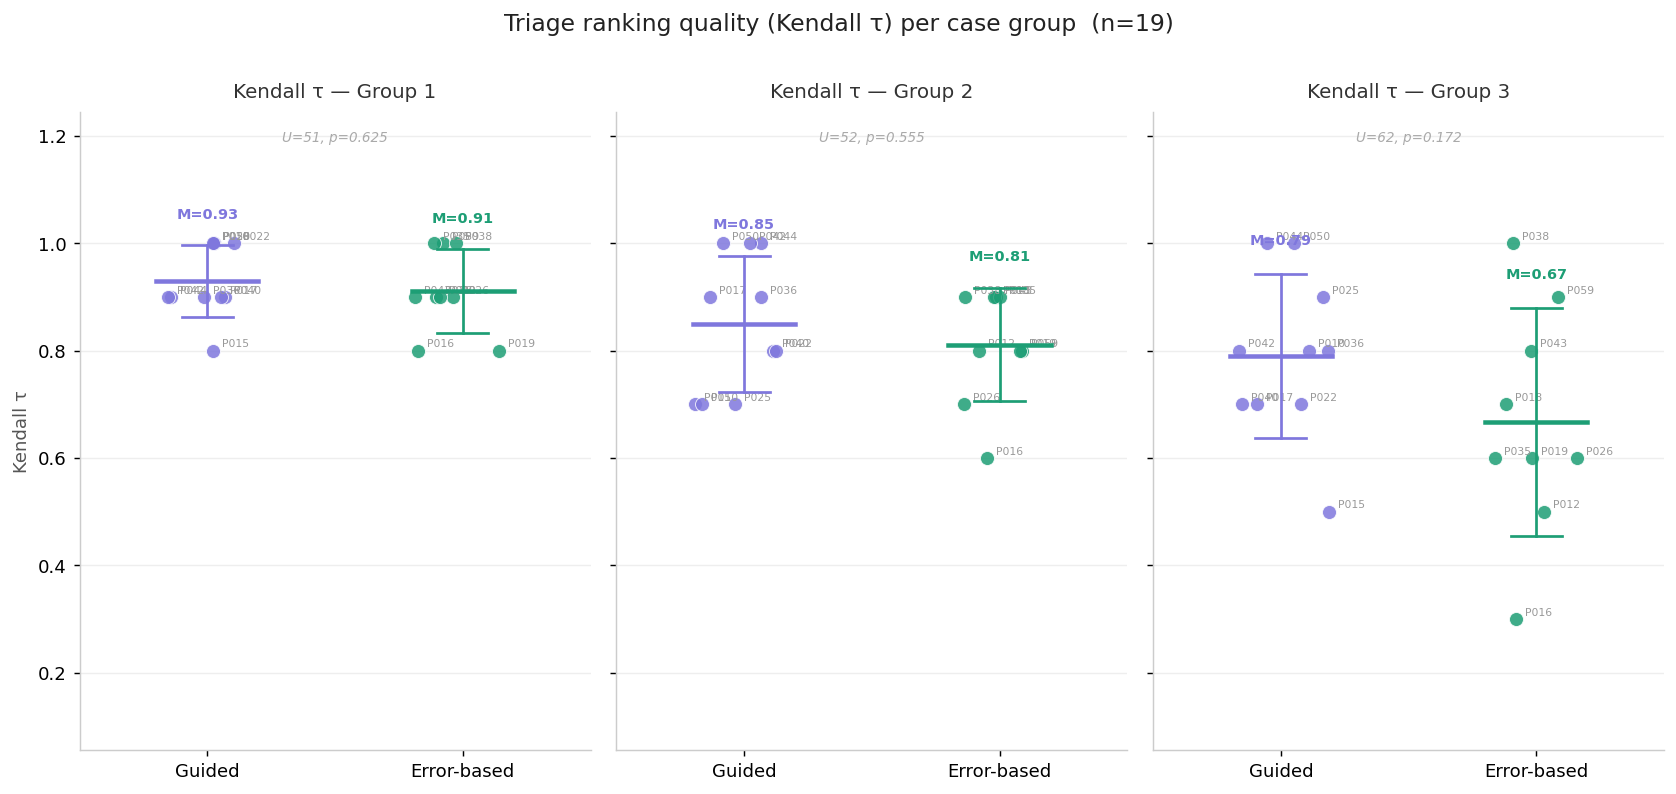

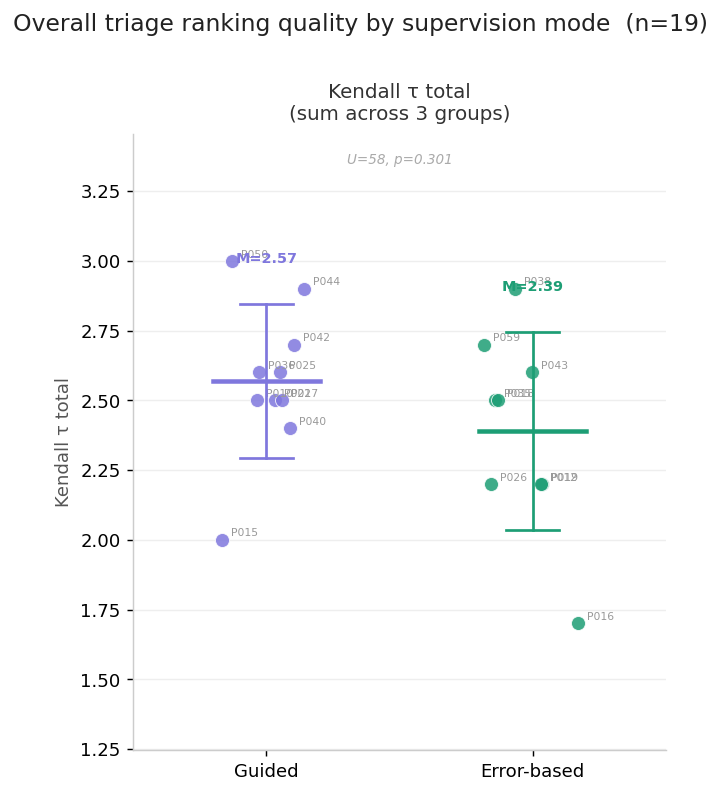

In [ ]:


def strip_panel(ax, df, col, title, y_max, y_min=None):
    """Draw one strip-plot panel with participant labels and mean±SD."""
    ax.set_facecolor("white")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#CCCCCC")

    for mode in MODES:
        vals = df.loc[df["mode"] == mode, col].dropna().reset_index(drop=True)
        x0   = X[mode]
        c    = COLORS[mode]
        n    = len(vals)

        # dots with jitter
        xs = x0 + rng.uniform(-0.10, 0.10, n)
        ax.scatter(xs, vals, color=c, s=60, alpha=0.85,
                   edgecolors="white", linewidths=0.5, zorder=3)

        # participant ID labels
        for xi, yi, pid in zip(xs, vals, df.loc[df["mode"] == mode, "participant_id"].values):
            ax.annotate(pid, xy=(xi, yi), xytext=(5, 2),
                        textcoords="offset points", fontsize=6, color="#999999")

        # mean ± SD crosshair
        m, sd = vals.mean(), vals.std(ddof=1)
        ax.plot([x0 - 0.10, x0 + 0.10], [m, m], color=c, lw=2.5, zorder=5)
        ax.plot([x0, x0], [m - sd, m + sd], color=c, lw=1.5, zorder=5)
        for cap in [m - sd, m + sd]:
            ax.plot([x0 - 0.05, x0 + 0.05], [cap, cap], color=c, lw=1.5, zorder=5)
        ax.text(x0, m + sd + (y_max * 0.04), f"M={m:.2f}",
                ha="center", va="bottom", fontsize=8, color=c, fontweight="bold")

    # Mann-Whitney annotation
    a = df.loc[df["mode"] == "guided",      col].dropna()
    b = df.loc[df["mode"] == "error_based", col].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    p_str = f"p={p:.3f}" if p >= 0.001 else "p<.001"
    ax.text(0.5, 0.97, f"U={u:.0f}, {p_str}", transform=ax.transAxes,
            ha="center", va="top", fontsize=7.5, color="#aaaaaa", style="italic")

    ax.set_title(title, fontsize=11, pad=8, color="#333333")
    ax.set_xlim(0, 1)
    ax.set_ylim(y_min if y_min is not None else -0.5, y_max)
    ax.set_xticks([0.25, 0.75])
    ax.set_xticklabels(["Guided", "Error-based"], fontsize=10)
    ax.grid(axis="y", color="#EEEEEE", linewidth=0.8, zorder=0)


# ── Figure 1: score outcomes ──────────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 3, figsize=(13, 6), sharey=False)
fig1.patch.set_facecolor("white")

strip_panel(axes1[0], df, "test_total",      "Total score (max 30)",      32)
strip_panel(axes1[1], df, "test_sel_total",  "Selection score (max 15)",  17)
strip_panel(axes1[2], df, "test_dest_total", "Destination score (max 15)", 17)

for ax in axes1:
    ax.set_ylabel("Score", fontsize=10, color="#555555")

fig1.suptitle(f"Test-phase performance by supervision mode  (n={len(df)})",
              fontsize=13, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("fig1_scores.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()




### 3.2. Kendall tau

In [ ]:
# ── Figure 2: Kendall tau per group (auto y-axis) ────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(13, 6), sharey=True)
fig2.patch.set_facecolor("white")

for ax, g in zip(axes2, (1, 2, 3)):
    col  = f"test_g{g}_kendall_tau"
    vals = df[col].dropna()
    pad  = (vals.max() - vals.min()) * 0.35   # 35% padding above/below
    strip_panel(ax, df, col,
                f"Kendall τ — Group {g}",
                y_max=vals.max() + pad,
                y_min=vals.min() - pad)
    ax.axhline(0, color="#cccccc", lw=1, linestyle="--", zorder=0)

axes2[0].set_ylabel("Kendall τ", fontsize=10, color="#555555")
fig2.suptitle(f"Triage ranking quality (Kendall τ) per case group  (n={len(df)})",
              fontsize=13, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("fig2_kendall_by_group.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()


# ── Figure 3: Kendall tau total (standalone) ─────────────────────────────────
col  = "test_kendall_tau_total"
vals = df[col].dropna()
pad  = (vals.max() - vals.min()) * 0.35

fig3, ax3 = plt.subplots(figsize=(5, 6))
fig3.patch.set_facecolor("white")

strip_panel(ax3, df, col,
            "Kendall τ total\n(sum across 3 groups)",
            y_max=vals.max() + pad,
            y_min=vals.min() - pad)

ax3.set_ylabel("Kendall τ total", fontsize=10, color="#555555")
fig3.suptitle(f"Overall triage ranking quality by supervision mode  (n={len(df)})",
              fontsize=13, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("fig3_kendall_total.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

#### (duration tested - not related to any analysis)

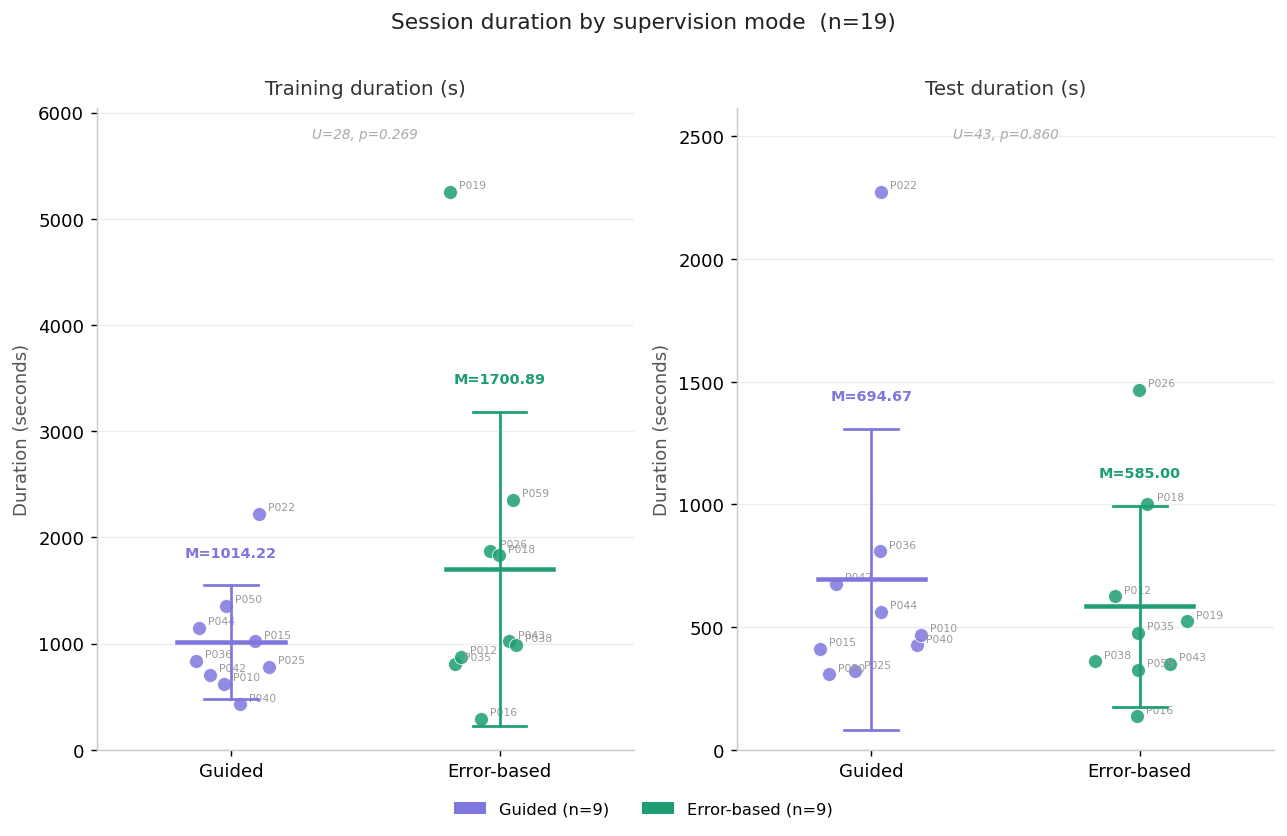

In [18]:
df_duration = df[df["participant_id"] != "P017"].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=False)
fig.patch.set_facecolor("white")

strip_panel(axes[0], df_duration, "train_duration_sec",
            "Training duration (s)",
            y_max=df_duration["train_duration_sec"].max() * 1.15,
            y_min=0)

strip_panel(axes[1], df_duration, "test_duration_sec",
            "Test duration (s)",
            y_max=df_duration["test_duration_sec"].max() * 1.15,
            y_min=0)

for ax in axes:
    ax.set_ylabel("Duration (seconds)", fontsize=10, color="#555555")

handles = [mpatches.Patch(facecolor=COLORS[m],
           label=f"{'Guided' if m=='guided' else 'Error-based'} (n={len(df_duration[df_duration['mode']==m])})")
           for m in MODES]
fig.legend(handles=handles, loc="lower center", ncol=2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))

fig.suptitle(f"Session duration by supervision mode  (n={len(df)})",
             fontsize=12, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("duration_by_mode.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

## 2. Cognitive load and subjective experience by supervision mode



### 2.1. NASA-TLX

In [ ]:

# ── Reverse-score performance (0=Poor→100=Good becomes 100=burden→0=no burden)
df["nasa_performance_r"] = 100 - df["nasa_performance"]

# ── Recompute correct burden composite (all 6 pointing in same direction)
BURDEN_DIMS = ["nasa_mental", "nasa_physical", "nasa_temporal",
               "nasa_performance_r", "nasa_effort", "nasa_frustration"]
df["nasa_burden_mean"] = df[BURDEN_DIMS].mean(axis=1)

# ── Theoretically relevant subscales for learning context
FOCAL_DIMS = ["nasa_mental", "nasa_effort", "nasa_frustration"]

print("=" * 60)
print("2.1a — NASA-TLX descriptive statistics by mode")
print("=" * 60)
dims_to_show = BURDEN_DIMS + ["nasa_burden_mean"]
rows = []
for dim in dims_to_show:
    for mode in MODES:
        vals = df.loc[df["mode"] == mode, dim].dropna()
        rows.append({
            "Dimension": dim,
            "Mode":      mode,
            "n":         len(vals),
            "Mean":      round(vals.mean(), 1),
            "SD":        round(vals.std(ddof=1), 1),
            "Median":    round(vals.median(), 1),
            "Min":       vals.min(),
            "Max":       vals.max(),
        })
print(pd.DataFrame(rows).to_string(index=False))




2.1a — NASA-TLX descriptive statistics by mode
         Dimension        Mode  n  Mean   SD  Median       Min        Max
       nasa_mental      guided 10  82.0 11.1    82.5 65.000000 100.000000
       nasa_mental error_based  9  80.6 15.3    80.0 50.000000 100.000000
     nasa_physical      guided 10  12.0 13.2    10.0  0.000000  35.000000
     nasa_physical error_based  9  18.3 20.3    10.0  0.000000  50.000000
     nasa_temporal      guided 10  60.0 29.1    57.5 15.000000 100.000000
     nasa_temporal error_based  9  51.1 20.4    50.0 20.000000  85.000000
nasa_performance_r      guided 10  50.5 26.9    50.0 10.000000  85.000000
nasa_performance_r error_based  9  57.8 22.9    50.0 10.000000  85.000000
       nasa_effort      guided 10  63.0 16.2    65.0 35.000000  90.000000
       nasa_effort error_based  9  67.2 21.1    70.0 25.000000  95.000000
  nasa_frustration      guided 10  53.0 19.3    52.5 30.000000 100.000000
  nasa_frustration error_based  9  70.0 23.0    75.0 30.000000 10

In [ ]:

# ── Cronbach's alpha for the focal 3 items ────────────────────────────────────
def cronbach_alpha(df_items):
    """Compute Cronbach's alpha from a DataFrame of items (rows=participants)."""
    k    = df_items.shape[1]
    item_var  = df_items.var(axis=0, ddof=1).sum()
    total_var = df_items.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var / total_var)

alpha_focal = cronbach_alpha(df[FOCAL_DIMS].dropna())
alpha_all   = cronbach_alpha(df[BURDEN_DIMS].dropna())

print(f"  Focal 3 (mental, effort, frustration) : α = {alpha_focal:.3f}")
print(f"  All 6 burden dimensions               : α = {alpha_all:.3f}")
print(f"  Threshold for composite use: α > 0.70")
print(f"  {'→ Composite justified' if alpha_focal > 0.70 else '→ Keep items separate — composite not justified'} (focal 3)")




2.1b — Cronbach's alpha
  Focal 3 (mental, effort, frustration) : α = 0.420
  All 6 burden dimensions               : α = 0.514
  Threshold for composite use: α > 0.70
  → Keep items separate — composite not justified (focal 3)



Main df (all analyses):  n = 19
NASA df (NASA analyses): n = 18
  Guided      : 10
  Error-based : 8
  Excluded    : ['P026'] (all-default NASA responses)


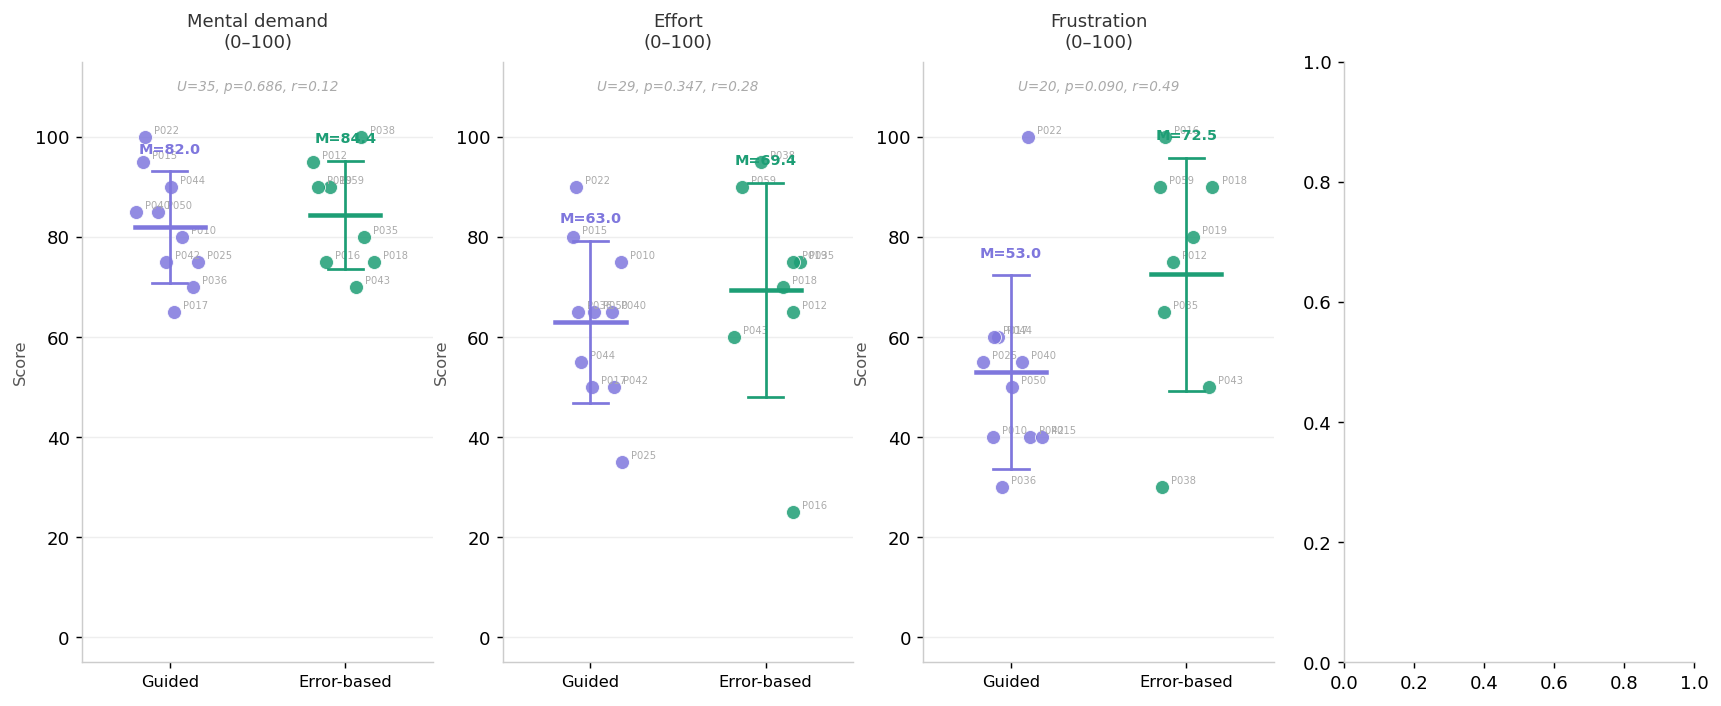

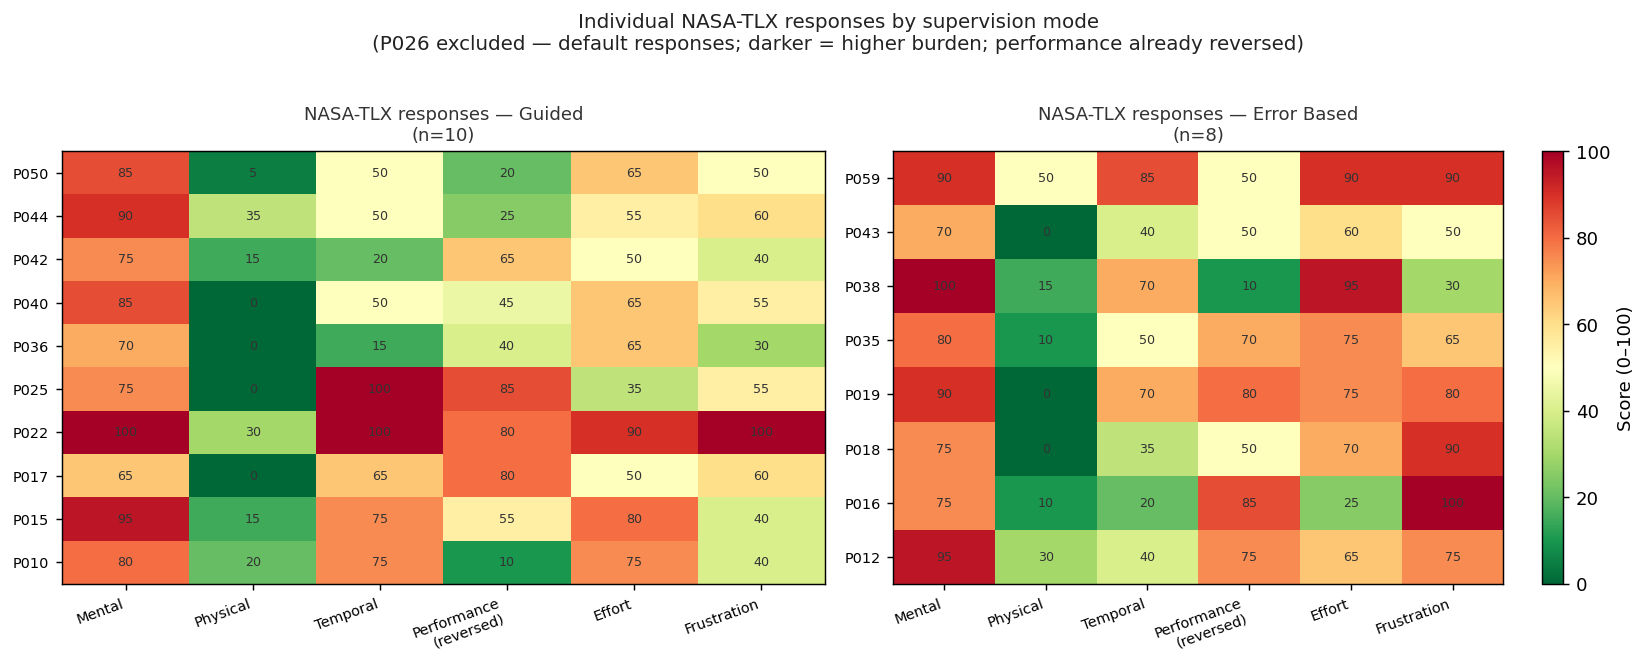

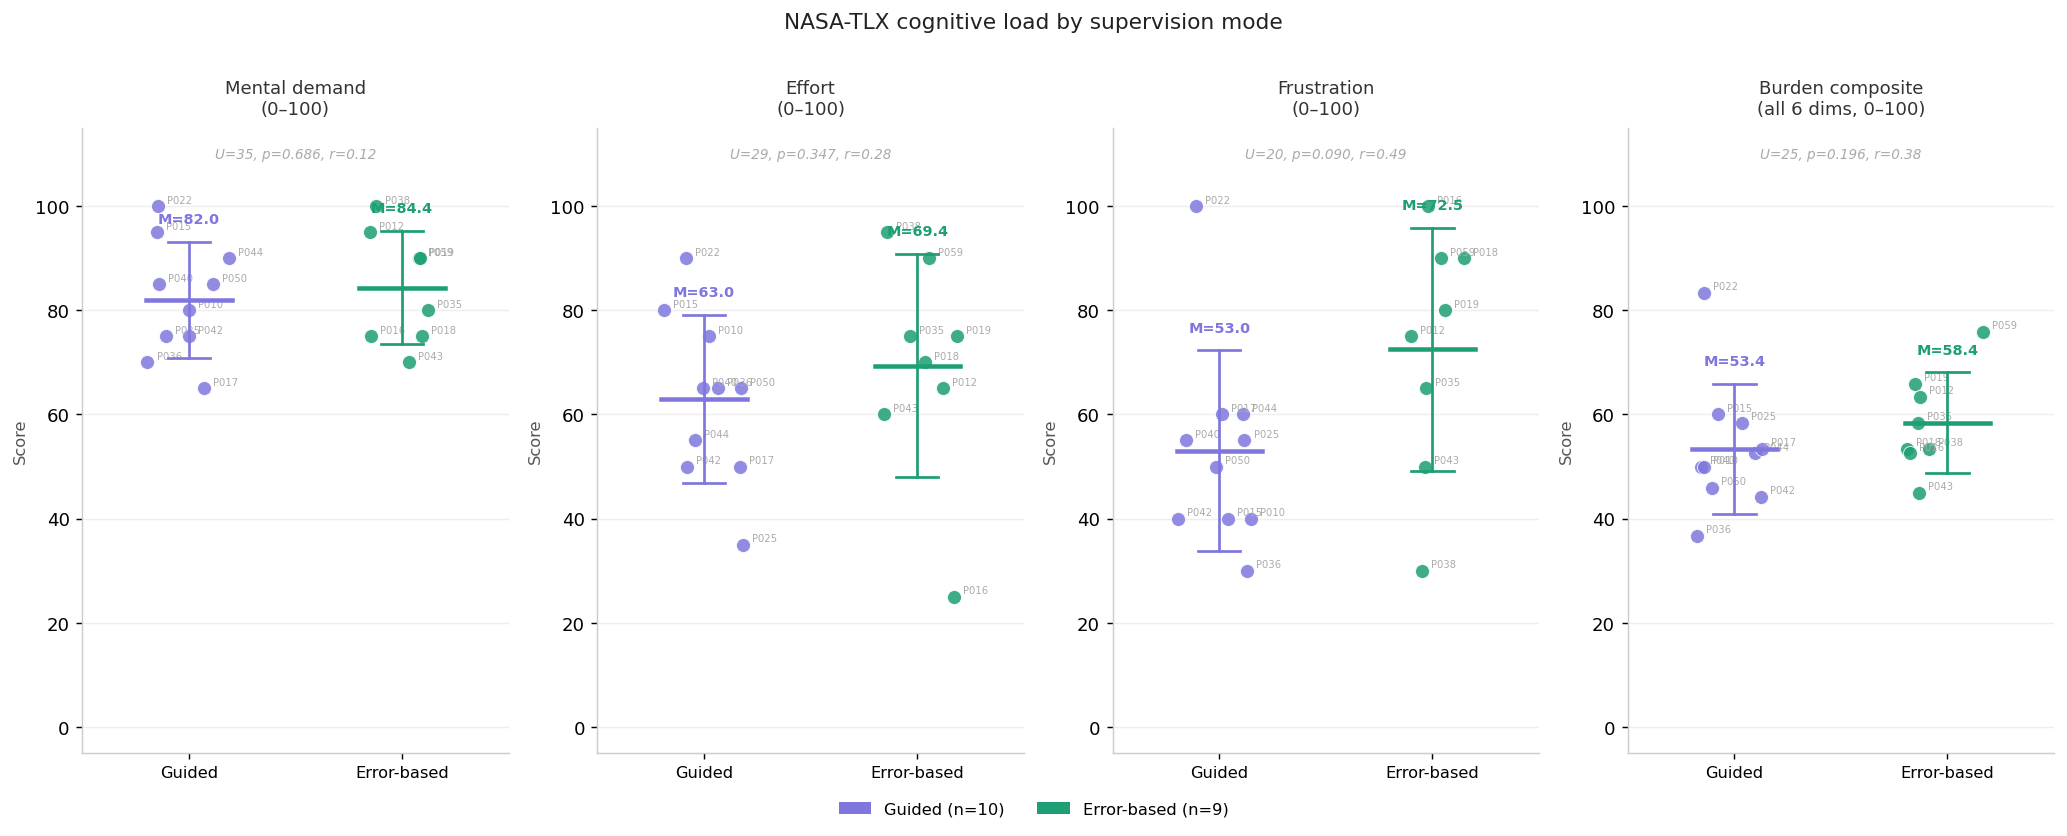

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import mannwhitneyu

# ── P026: NASA default responses — exclude from all NASA analyses ─────────────
NASA_EXCLUDE = ["P026"]

df_nasa = df[~df["participant_id"].isin(NASA_EXCLUDE)].copy()

print(f"\nMain df (all analyses):  n = {len(df)}")
print(f"NASA df (NASA analyses): n = {len(df_nasa)}")
print(f"  Guided      : {(df_nasa['mode']=='guided').sum()}")
print(f"  Error-based : {(df_nasa['mode']=='error_based').sum()}")
print(f"  Excluded    : {NASA_EXCLUDE} (all-default NASA responses)")

# ── Variability exploration — heatmap of individual responses ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")

for ax, mode in zip(axes, MODES):
    sub = df_nasa[df_nasa["mode"] == mode][["participant_id"] + BURDEN_DIMS].set_index("participant_id")
    sub.columns = ["Mental", "Physical", "Temporal", "Performance\n(reversed)",
                   "Effort", "Frustration"]
    im = ax.imshow(sub.values, aspect="auto", cmap="RdYlGn_r",
                   vmin=0, vmax=100)
    ax.set_xticks(range(len(sub.columns)))
    ax.set_xticklabels(sub.columns, fontsize=8, rotation=20, ha="right")
    ax.set_yticks(range(len(sub.index)))
    ax.set_yticklabels(sub.index, fontsize=8)
    ax.set_title(f"NASA-TLX responses — {mode.replace('_',' ').title()}\n(n={len(sub)})",
                 fontsize=10, color="#333333")
    for i in range(len(sub.index)):
        for j in range(len(sub.columns)):
            ax.text(j, i, f"{sub.values[i,j]:.0f}",
                    ha="center", va="center", fontsize=7, color="#333333")

plt.colorbar(im, ax=axes[1], label="Score (0–100)")
fig.suptitle("Individual NASA-TLX responses by supervision mode\n"
             "(P026 excluded — default responses; darker = higher burden; performance already reversed)",
             fontsize=11, color="#222222", y=1.02)
plt.tight_layout()
plt.savefig("nasa_heatmap.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()


# ── Strip plots + Mann-Whitney for focal dims + burden composite ──────────────
def strip_panel(ax, df, col, title, y_min=None, y_max=None):
    ax.set_facecolor("white")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#CCCCCC")
    X = {"guided": 0.25, "error_based": 0.75}

    for mode in MODES:
        vals = df.loc[df["mode"] == mode, col].dropna().reset_index(drop=True)
        x0, c = X[mode], COLORS[mode]
        xs = x0 + rng.uniform(-0.10, 0.10, len(vals))
        ax.scatter(xs, vals, color=c, s=60, alpha=0.85,
                   edgecolors="white", linewidths=0.5, zorder=3)
        for xi, yi, pid in zip(xs, vals,
                                df.loc[df["mode"] == mode, "participant_id"].values):
            ax.annotate(pid, xy=(xi, yi), xytext=(5, 2),
                        textcoords="offset points", fontsize=5.5, color="#aaaaaa")
        m, sd = vals.mean(), vals.std(ddof=1)
        ax.plot([x0-.10, x0+.10], [m, m], color=c, lw=2.5, zorder=5)
        ax.plot([x0, x0], [m-sd, m+sd], color=c, lw=1.5, zorder=5)
        for cap in [m-sd, m+sd]:
            ax.plot([x0-.05, x0+.05], [cap, cap], color=c, lw=1.5, zorder=5)
        ax.text(x0, m+sd+3, f"M={m:.1f}", ha="center", va="bottom",
                fontsize=8, color=c, fontweight="bold")

    a = df.loc[df["mode"] == "guided",      col].dropna()
    b = df.loc[df["mode"] == "error_based", col].dropna()
    u, p = mannwhitneyu(a, b, alternative="two-sided")
    r    = 1 - (2*u) / (len(a)*len(b))
    p_str = f"p={p:.3f}" if p >= 0.001 else "p<.001"
    ax.text(0.5, 0.97, f"U={u:.0f}, {p_str}, r={r:.2f}",
            transform=ax.transAxes, ha="center", va="top",
            fontsize=7.5, color="#aaaaaa", style="italic")

    ax.set_title(title, fontsize=10, pad=8, color="#333333")
    ax.set_xlim(0, 1)
    auto_min = df[col].min() - 10 if y_min is None else y_min
    auto_max = df[col].max() + 15 if y_max is None else y_max
    ax.set_ylim(auto_min, auto_max)
    ax.set_xticks([0.25, 0.75])
    ax.set_xticklabels(["Guided", "Error-based"], fontsize=9)
    ax.grid(axis="y", color="#EEEEEE", linewidth=0.8, zorder=0)


plot_dims = [
    ("nasa_mental",      "Mental demand\n(0–100)"),
    ("nasa_effort",      "Effort\n(0–100)"),
    ("nasa_frustration", "Frustration\n(0–100)"),
    ("nasa_burden_mean", "Burden composite\n(all 6 dims, 0–100)"),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=False)
fig.patch.set_facecolor("white")

for ax, (col, title) in zip(axes, plot_dims):
    strip_panel(ax, df_nasa, col, title, y_min=-5, y_max=115)
    ax.set_ylabel("Score", fontsize=9, color="#555555")

handles = [mpatches.Patch(facecolor=COLORS[m],
           label=f"{'Guided' if m=='guided' else 'Error-based'} (n={len(df[df['mode']==m])})")
           for m in MODES]
fig.legend(handles=handles, loc="lower center", ncol=2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("NASA-TLX cognitive load by supervision mode",
             fontsize=12, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("nasa_by_mode.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()



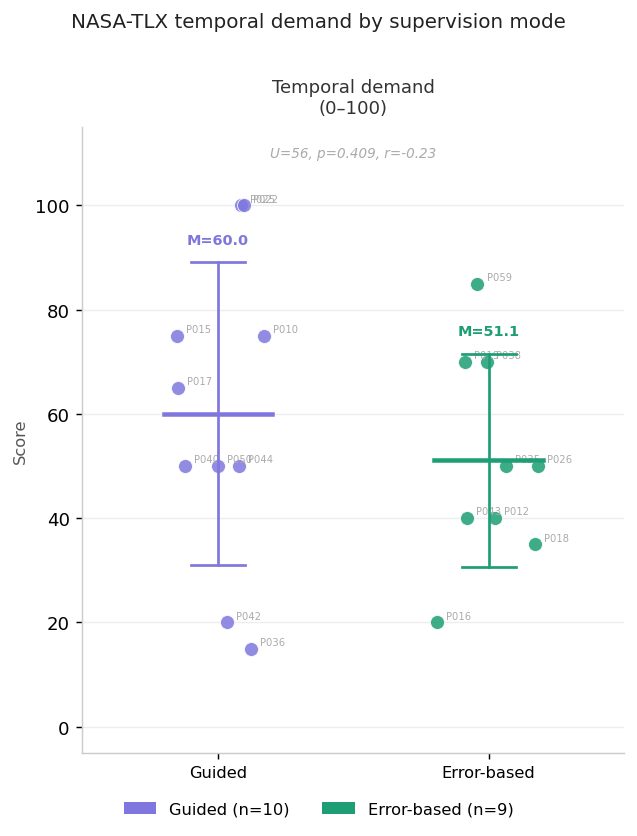

In [9]:
# ── Temporal demand — standalone figure ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 6))
fig.patch.set_facecolor("white")

strip_panel(ax, df, "nasa_temporal", "Temporal demand\n(0–100)", y_min=-5, y_max=115)
ax.set_ylabel("Score", fontsize=9, color="#555555")

handles = [mpatches.Patch(facecolor=COLORS[m],
           label=f"{'Guided' if m=='guided' else 'Error-based'} (n={len(df[df['mode']==m])})")
           for m in MODES]
fig.legend(handles=handles, loc="lower center", ncol=2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))

fig.suptitle("NASA-TLX temporal demand by supervision mode",
             fontsize=11, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("nasa_temporal.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

In [24]:

# ── Mann-Whitney summary table ────────────────────────────────────────────────
print("\n2.1c — Mann-Whitney U results (NASA-TLX)")
mw_rows = []
for col, label in plot_dims:
    a = df.loc[df["mode"] == "guided",      col].dropna()
    b = df.loc[df["mode"] == "error_based", col].dropna()
    u, p = mannwhitneyu(a, b, alternative="two-sided")
    r    = round(1 - (2*u)/(len(a)*len(b)), 3)
    mw_rows.append({"Dimension": label.replace("\n"," "),
                    "U": u, "p": round(p,3), "r": r,
                    "sig": "n.s." if p>.05 else "*"})
print(pd.DataFrame(mw_rows).to_string(index=False))





2.1c — Mann-Whitney U results (NASA-TLX)
                           Dimension    U     p     r  sig
               Mental demand (0–100) 45.0 1.000 0.000 n.s.
                      Effort (0–100) 37.0 0.537 0.178 n.s.
                 Frustration (0–100) 26.0 0.129 0.422 n.s.
Burden composite (all 6 dims, 0–100) 31.0 0.268 0.311 n.s.


### 2.2. Subjective appraisal


2.2 — Subjective appraisal by mode


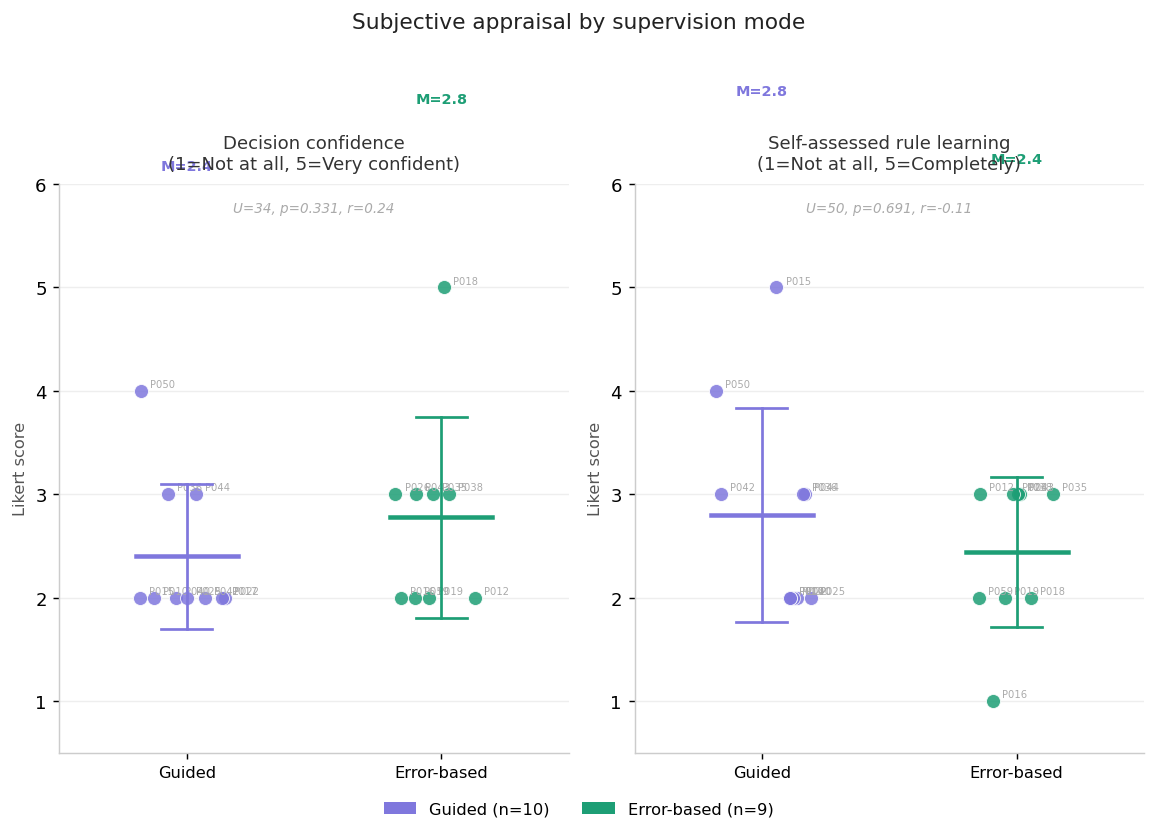


Discrepancy check — mean confidence vs mean test_total:
  guided        confidence=2.40/5   test_total=18.2/30 (61%)
  error_based   confidence=2.78/5   test_total=17.0/30 (57%)


In [25]:
# ════════════════════════════════════════════════════════════════════════════
# 2.2  Subjective appraisal — q_q2 (confidence) and q_q6 (self-assessed
#      rule learning) by mode; flag discrepancy with actual performance
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("2.2 — Subjective appraisal by mode")
print("="*60)

SUBJ_ITEMS = [
    ("q_q2", "Decision confidence\n(1=Not at all, 5=Very confident)"),
    ("q_q6", "Self-assessed rule learning\n(1=Not at all, 5=Completely)"),
]

fig, axes = plt.subplots(1, 2, figsize=(9, 6))
fig.patch.set_facecolor("white")

for ax, (col, title) in zip(axes, SUBJ_ITEMS):
    strip_panel(ax, df, col, title, y_min=0.5, y_max=6.0)
    ax.set_ylabel("Likert score", fontsize=9, color="#555555")
    ax.yaxis.set_major_locator(plt.MultipleLocator(1))

fig.legend(handles=handles, loc="lower center", ncol=2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Subjective appraisal by supervision mode",
             fontsize=12, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("subjective_appraisal.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

# ── Discrepancy: confidence vs actual performance ─────────────────────────────
print("\nDiscrepancy check — mean confidence vs mean test_total:")
for mode in MODES:
    sub = df[df["mode"] == mode]
    conf  = sub["q_q2"].mean()
    score = sub["test_total"].mean()
    score_pct = score / 30 * 100
    print(f"  {mode:12s}  confidence={conf:.2f}/5   "
          f"test_total={score:.1f}/30 ({score_pct:.0f}%)")

## 3. Predictors of performance - exploratory regression

### 3.1. Correlation Matrix

Spearman correlations with Kendall τ total
             Predictor  n    r_s     p  sig
   Decision confidence 19  0.432 0.065 n.s.
           Frustration 19 -0.338 0.158 n.s.
      Burden composite 19 -0.304 0.206 n.s.
Self-assessed learning 19  0.295 0.221 n.s.
         Train time(S) 19  0.087 0.723 n.s.
                Effort 19  0.081 0.741 n.s.
    Rule consultations 19 -0.077 0.754 n.s.
 Rule consult time (s) 19 -0.066 0.789 n.s.
         Task time (s) 19 -0.057 0.817 n.s.
         Mental demand 19  0.052 0.833 n.s.


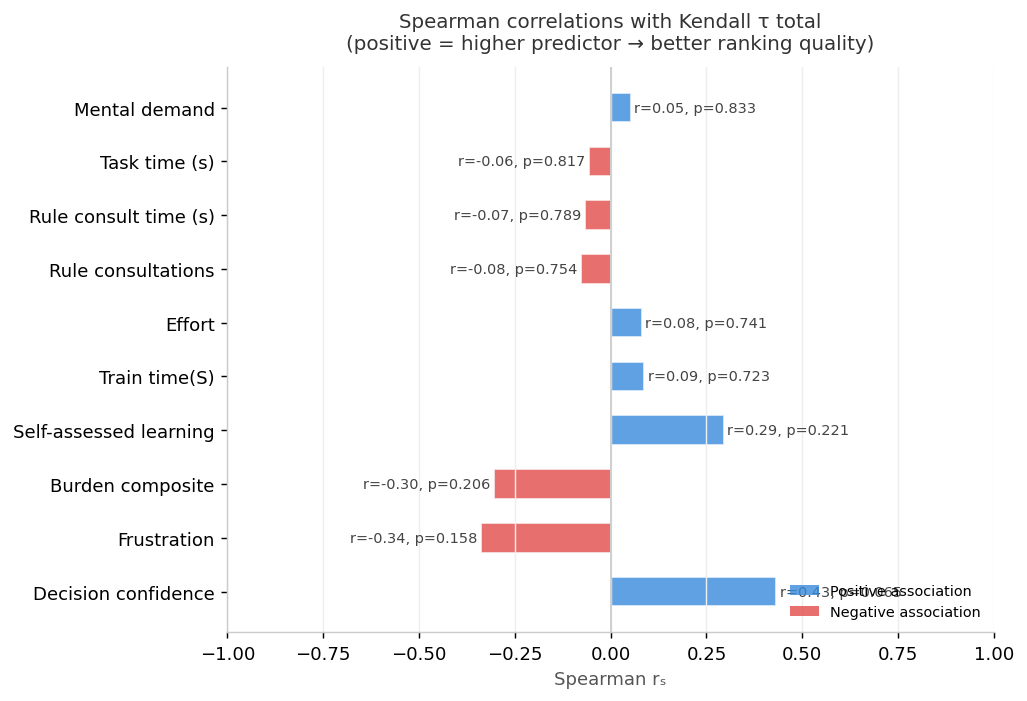

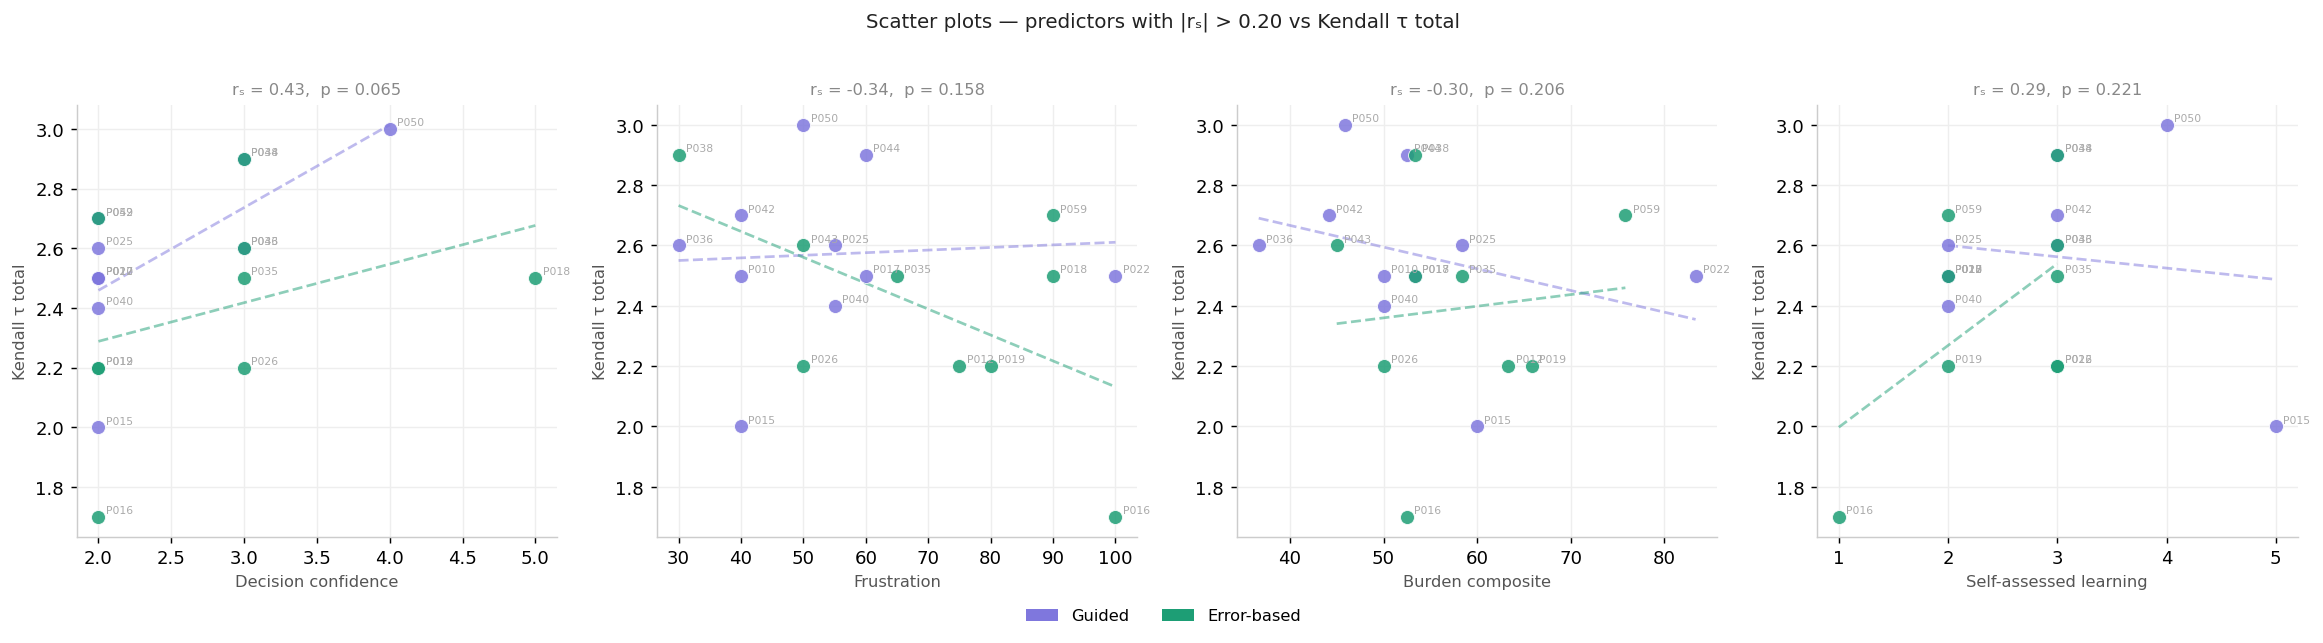

In [29]:
# ════════════════════════════════════════════════════════════════════════════
# 3.1 — Spearman correlation matrix
#       Candidate predictors vs. test_kendall_tau_total
# ════════════════════════════════════════════════════════════════════════════

# ── Outlier-corrected task time ───────────────────────────────────────────────
time_cols = [f"test_g{g}_{pt}_time_sec"
             for g in (1, 2, 3) for pt in ("selection", "destinations")]
df["test_task_time_total"] = df[time_cols].fillna(0).sum(axis=1)

Q1, Q3 = df["test_task_time_total"].quantile(0.25), df["test_task_time_total"].quantile(0.75)
upper   = Q3 + 1.5 * (Q3 - Q1)
mean_clean = df.loc[df["test_task_time_total"] <= upper, "test_task_time_total"].mean()
df.loc[df["test_task_time_total"] > upper, "test_task_time_total"] = mean_clean

# ── Kendall tau total ─────────────────────────────────────────────────────────
df["test_kendall_tau_total"] = (df["test_g1_kendall_tau"] +
                                df["test_g2_kendall_tau"] +
                                df["test_g3_kendall_tau"])

# ── Define predictors ─────────────────────────────────────────────────────────
PREDICTORS = {
    "nasa_mental":           "Mental demand",
    "nasa_effort":           "Effort",
    "nasa_frustration":      "Frustration",
    "nasa_burden_mean":      "Burden composite",
    "test_rule_consult":     "Rule consultations",
    "test_rule_time_sec":    "Rule consult time (s)",
    "test_task_time_total":  "Task time (s)",
    "train_duration_sec":        "Train time(S)",
    "q_q2":                  "Decision confidence",
    "q_q6":                  "Self-assessed learning",
}

OUTCOME = "test_kendall_tau_total"
OUTCOME_LABEL = "Kendall τ total"

# ── Compute Spearman correlations ─────────────────────────────────────────────
from scipy.stats import spearmanr

corr_rows = []
for col, label in PREDICTORS.items():
    valid = df[[col, OUTCOME]].dropna()
    r, p  = spearmanr(valid[col], valid[OUTCOME])
    corr_rows.append({
        "Predictor":  label,
        "column":     col,
        "n":          len(valid),
        "r_s":        round(r, 3),
        "p":          round(p, 3),
        "sig":        "n.s." if p > .05 else ("*" if p > .01 else "**"),
    })

corr_df = pd.DataFrame(corr_rows).sort_values("r_s", key=abs, ascending=False)
print("Spearman correlations with", OUTCOME_LABEL)
print(corr_df[["Predictor", "n", "r_s", "p", "sig"]].to_string(index=False))

# ── Visualise: horizontal bar chart of r_s ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#CCCCCC")

bar_colors = ["#E24B4A" if r < 0 else "#378ADD" for r in corr_df["r_s"]]
bars = ax.barh(corr_df["Predictor"], corr_df["r_s"],
               color=bar_colors, alpha=0.80, edgecolor="white", height=0.55)

# significance markers
for i, (_, row) in enumerate(corr_df.iterrows()):
    x_off = 0.01 if row["r_s"] >= 0 else -0.01
    ha    = "left" if row["r_s"] >= 0 else "right"
    label = f"r={row['r_s']:.2f}, p={row['p']:.3f}"
    if row["sig"] != "n.s.":
        label += f" {row['sig']}"
    ax.text(row["r_s"] + x_off, i, label,
            va="center", ha=ha, fontsize=8, color="#444444")

ax.axvline(0, color="#CCCCCC", lw=1)
ax.set_xlabel("Spearman rₛ", fontsize=10, color="#555555")
ax.set_title(f"Spearman correlations with {OUTCOME_LABEL}\n"
             f"(positive = higher predictor → better ranking quality)",
             fontsize=11, color="#333333", pad=10)
ax.set_xlim(-1, 1)
ax.grid(axis="x", color="#EEEEEE", linewidth=0.8, zorder=0)

# legend for colour
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(facecolor="#378ADD", alpha=0.8, label="Positive association"),
    mpatches.Patch(facecolor="#E24B4A", alpha=0.8, label="Negative association"),
]
ax.legend(handles=legend_handles, fontsize=8, frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig("spearman_correlations.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

# ── Scatter matrix for top predictors (|r| > 0.2) ────────────────────────────
top_preds = corr_df[corr_df["r_s"].abs() > 0.20]["column"].tolist()

if top_preds:
    n_top = len(top_preds)
    fig, axes = plt.subplots(1, n_top, figsize=(4.5 * n_top, 4.5))
    if n_top == 1:
        axes = [axes]
    fig.patch.set_facecolor("white")

    for ax, col in zip(axes, top_preds):
        label = PREDICTORS[col]
        for mode in MODES:
            sub = df[df["mode"] == mode][[col, OUTCOME]].dropna()
            ax.scatter(sub[col], sub[OUTCOME],
                       color=COLORS[mode], s=60, alpha=0.85,
                       edgecolors="white", linewidths=0.5, zorder=3,
                       label=mode.replace("_", "-").title())
            # regression line per mode
            if len(sub) > 2:
                m, b, *_ = stats.linregress(sub[col], sub[OUTCOME])
                x_line = np.linspace(sub[col].min(), sub[col].max(), 100)
                ax.plot(x_line, m * x_line + b,
                        color=COLORS[mode], lw=1.5, alpha=0.5, linestyle="--")
        # participant labels
        for _, row in df[[col, OUTCOME, "participant_id"]].dropna().iterrows():
            ax.annotate(row["participant_id"],
                        xy=(row[col], row[OUTCOME]),
                        xytext=(4, 2), textcoords="offset points",
                        fontsize=6, color="#aaaaaa")

        r_val = corr_df.loc[corr_df["column"] == col, "r_s"].values[0]
        p_val = corr_df.loc[corr_df["column"] == col, "p"].values[0]
        ax.set_xlabel(label, fontsize=9, color="#555555")
        ax.set_ylabel(OUTCOME_LABEL, fontsize=9, color="#555555")
        ax.set_title(f"rₛ = {r_val:.2f},  p = {p_val:.3f}",
                     fontsize=9, color="#888888", pad=6)
        ax.set_facecolor("white")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#CCCCCC")
        ax.grid(color="#EEEEEE", linewidth=0.8, zorder=0)

    handles = [mpatches.Patch(facecolor=COLORS[m],
               label=f"{'Guided' if m=='guided' else 'Error-based'}")
               for m in MODES]
    fig.legend(handles=handles, loc="lower center", ncol=2,
               fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle(f"Scatter plots — predictors with |rₛ| > 0.20 vs {OUTCOME_LABEL}",
                 fontsize=11, color="#222222", y=1.02)
    plt.tight_layout()
    plt.savefig("spearman_scatters.png", dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
else:
    print("No predictors with |rₛ| > 0.20 found.")

## (Code that provides the summary of all the results. Skip) 

In [31]:
# ── Output 1: Sample sizes ────────────────────────────────────────────────────
print(f"N total: {len(df)}")
print(df.groupby("mode")["participant_id"].count())

# ── Output 2: 1.1 Aggregate scores ───────────────────────────────────────────
for col, label in [("test_score_mean", "Mean score per group"),
                   ("test_sel_total",  "Selection total"),
                   ("test_dest_total", "Destination total")]:
    print(f"\n{label}")
    print(df.groupby("mode")[col].agg(["mean","std","median","min","max"]).round(2))
    a = df.loc[df["mode"]=="guided", col].dropna()
    b = df.loc[df["mode"]=="error_based", col].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    r = 1 - (2*u)/(len(a)*len(b))
    print(f"Mann-Whitney U={u:.0f}, p={p:.3f}, r={r:.3f}")

# ── Output 3: 1.2 Kendall tau ─────────────────────────────────────────────────
df["test_kendall_tau_total"] = (df["test_g1_kendall_tau"] +
                                df["test_g2_kendall_tau"] +
                                df["test_g3_kendall_tau"])
for col, label in [("test_g1_kendall_tau", "Kendall tau G1"),
                   ("test_g2_kendall_tau", "Kendall tau G2"),
                   ("test_g3_kendall_tau", "Kendall tau G3"),
                   ("test_kendall_tau_total", "Kendall tau total")]:
    print(f"\n{label}")
    print(df.groupby("mode")[col].agg(["mean","std","median","min","max"]).round(3))
    a = df.loc[df["mode"]=="guided", col].dropna()
    b = df.loc[df["mode"]=="error_based", col].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    r = 1 - (2*u)/(len(a)*len(b))
    print(f"Mann-Whitney U={u:.0f}, p={p:.3f}, r={r:.3f}")

# ── Output 4: q_q4 distribution ──────────────────────────────────────────────
print("\nq_q4 — most challenging phase:")
print(df["q_q4"].value_counts())

# ── Output 5: NASA-TLX ────────────────────────────────────────────────────────
print("\nCronbach alpha focal 3:")
print(round(cronbach_alpha(df_nasa[FOCAL_DIMS].dropna()), 3))
print("\nCronbach alpha all 6:")
print(round(cronbach_alpha(df_nasa[BURDEN_DIMS].dropna()), 3))

for col, label in [("nasa_mental",      "Mental demand"),
                   ("nasa_effort",       "Effort"),
                   ("nasa_frustration",  "Frustration"),
                   ("nasa_burden_mean",  "Burden composite")]:
    print(f"\n{label}")
    print(df_nasa.groupby("mode")[col].agg(["mean","std","median"]).round(2))
    a = df_nasa.loc[df_nasa["mode"]=="guided", col].dropna()
    b = df_nasa.loc[df_nasa["mode"]=="error_based", col].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    r = 1 - (2*u)/(len(a)*len(b))
    print(f"Mann-Whitney U={u:.0f}, p={p:.3f}, r={r:.3f}")

# ── Output 6: Subjective appraisal ───────────────────────────────────────────
for col, label in [("q_q2", "Decision confidence"),
                   ("q_q6", "Self-assessed learning")]:
    print(f"\n{label}")
    print(df.groupby("mode")[col].agg(["mean","std","median"]).round(2))
    a = df.loc[df["mode"]=="guided", col].dropna()
    b = df.loc[df["mode"]=="error_based", col].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    r = 1 - (2*u)/(len(a)*len(b))
    print(f"Mann-Whitney U={u:.0f}, p={p:.3f}, r={r:.3f}")

# ── Output 7: Performance vs confidence discrepancy ──────────────────────────
print("\nDiscrepancy — confidence vs actual performance:")
for mode in ["guided", "error_based"]:
    sub = df[df["mode"]==mode]
    print(f"  {mode}: confidence={sub['q_q2'].mean():.2f}/5, "
          f"test_score_mean={sub['test_score_mean'].mean():.2f}/10 "
          f"({sub['test_score_mean'].mean()/10*100:.0f}%)")

N total: 19
mode
error_based     9
guided         10
Name: participant_id, dtype: int64

Mean score per group
             mean   std  median   min    max
mode                                        
error_based  5.67  1.51    5.67  3.00   8.67
guided       6.30  1.88    6.00  4.33  10.00
Mann-Whitney U=52, p=0.623, r=-0.144

Selection total
             mean   std  median  min  max
mode                                     
error_based  7.22  3.31     7.0    1   13
guided       8.50  3.31     8.0    5   15
Mann-Whitney U=52, p=0.562, r=-0.167

Destination total
             mean   std  median  min   max
mode                                      
error_based  9.78  2.11    10.0  7.0  13.0
guided       9.70  2.06    10.5  5.0  12.0
Mann-Whitney U=50, p=0.741, r=-0.100

Kendall tau G1
              mean    std  median  min  max
mode                                       
error_based  0.911  0.078     0.9  0.8  1.0
guided       0.930  0.067     0.9  0.8  1.0
Mann-Whitney U=51, p=0.625, r=-

### 3.2. Normality Check

NORMALITY CHECKS — COVARIATES (per supervision mode group)

NOTE ON BOUNDED VARIABLES:
  q_q2 and q_q6 are 5-point ordinal scales (discrete, 1–5).
  Shapiro-Wilk is run for completeness but has near-zero power
  at n≈9-10 with only 5 possible values. The Q-Q plot is the
  more informative diagnostic for these variables.
  nasa_frustration (0–100 continuous) is more amenable to
  normality testing but remains bounded.

  Decision confidence (1–5) | guided       | n=10 | W=0.650, p=0.000  → REJECT normality
  Decision confidence (1–5) | error_based  | n=9 | W=0.752, p=0.006  → REJECT normality

  Frustration (0–100) | guided       | n=10 | W=0.838, p=0.042  → REJECT normality
  Frustration (0–100) | error_based  | n=8 | W=0.937, p=0.581  → fail to reject normality

  Self-assessed learning (1–5) | guided       | n=10 | W=0.791, p=0.011  → REJECT normality
  Self-assessed learning (1–5) | error_based  | n=9 | W=0.763, p=0.008  → REJECT normality



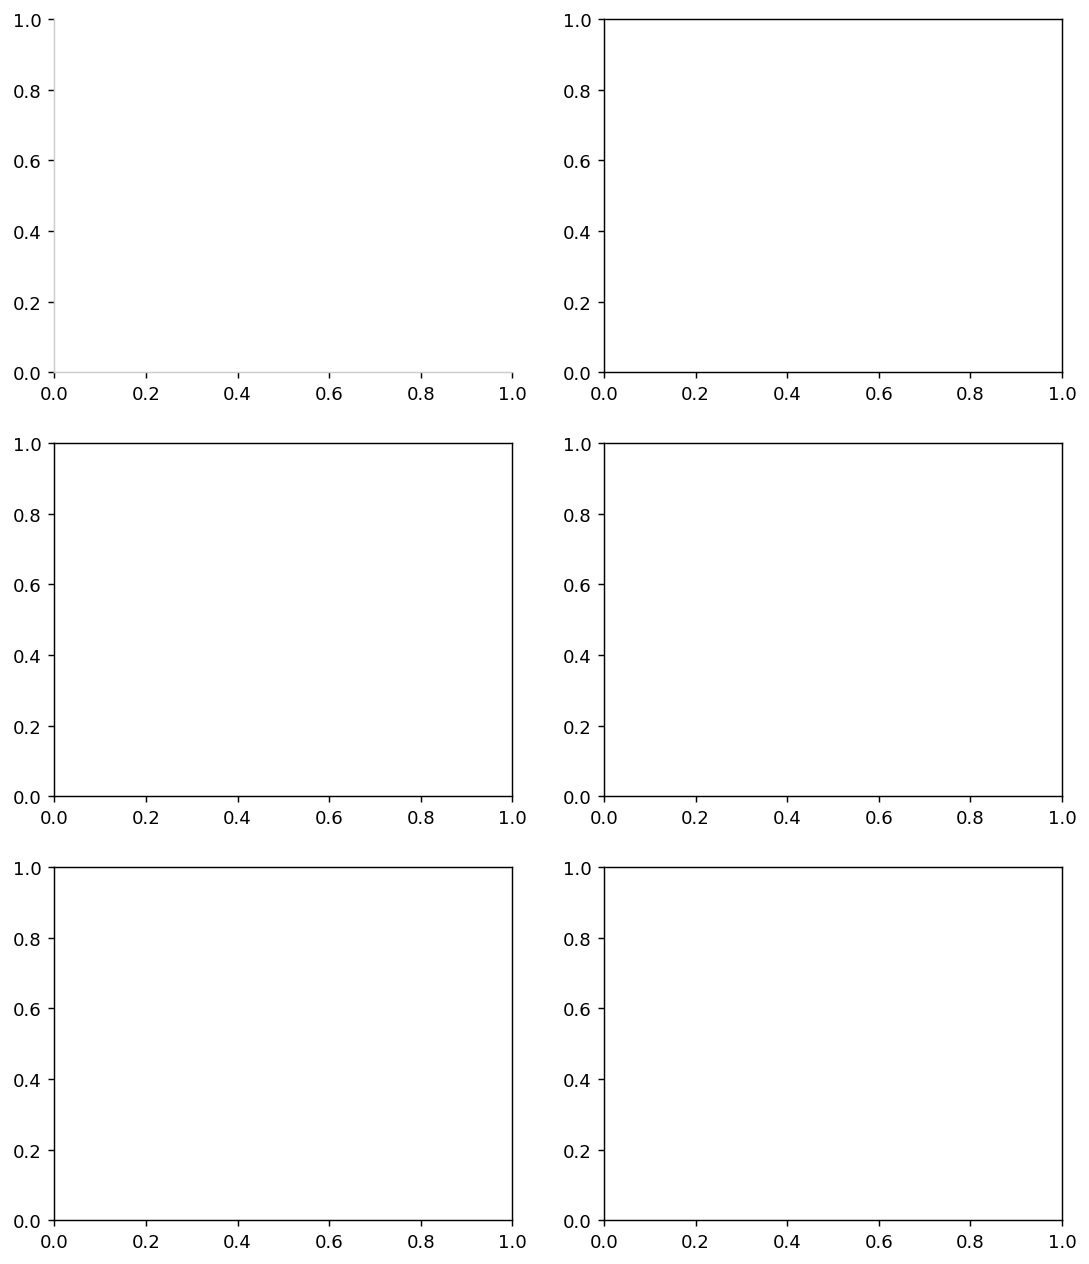

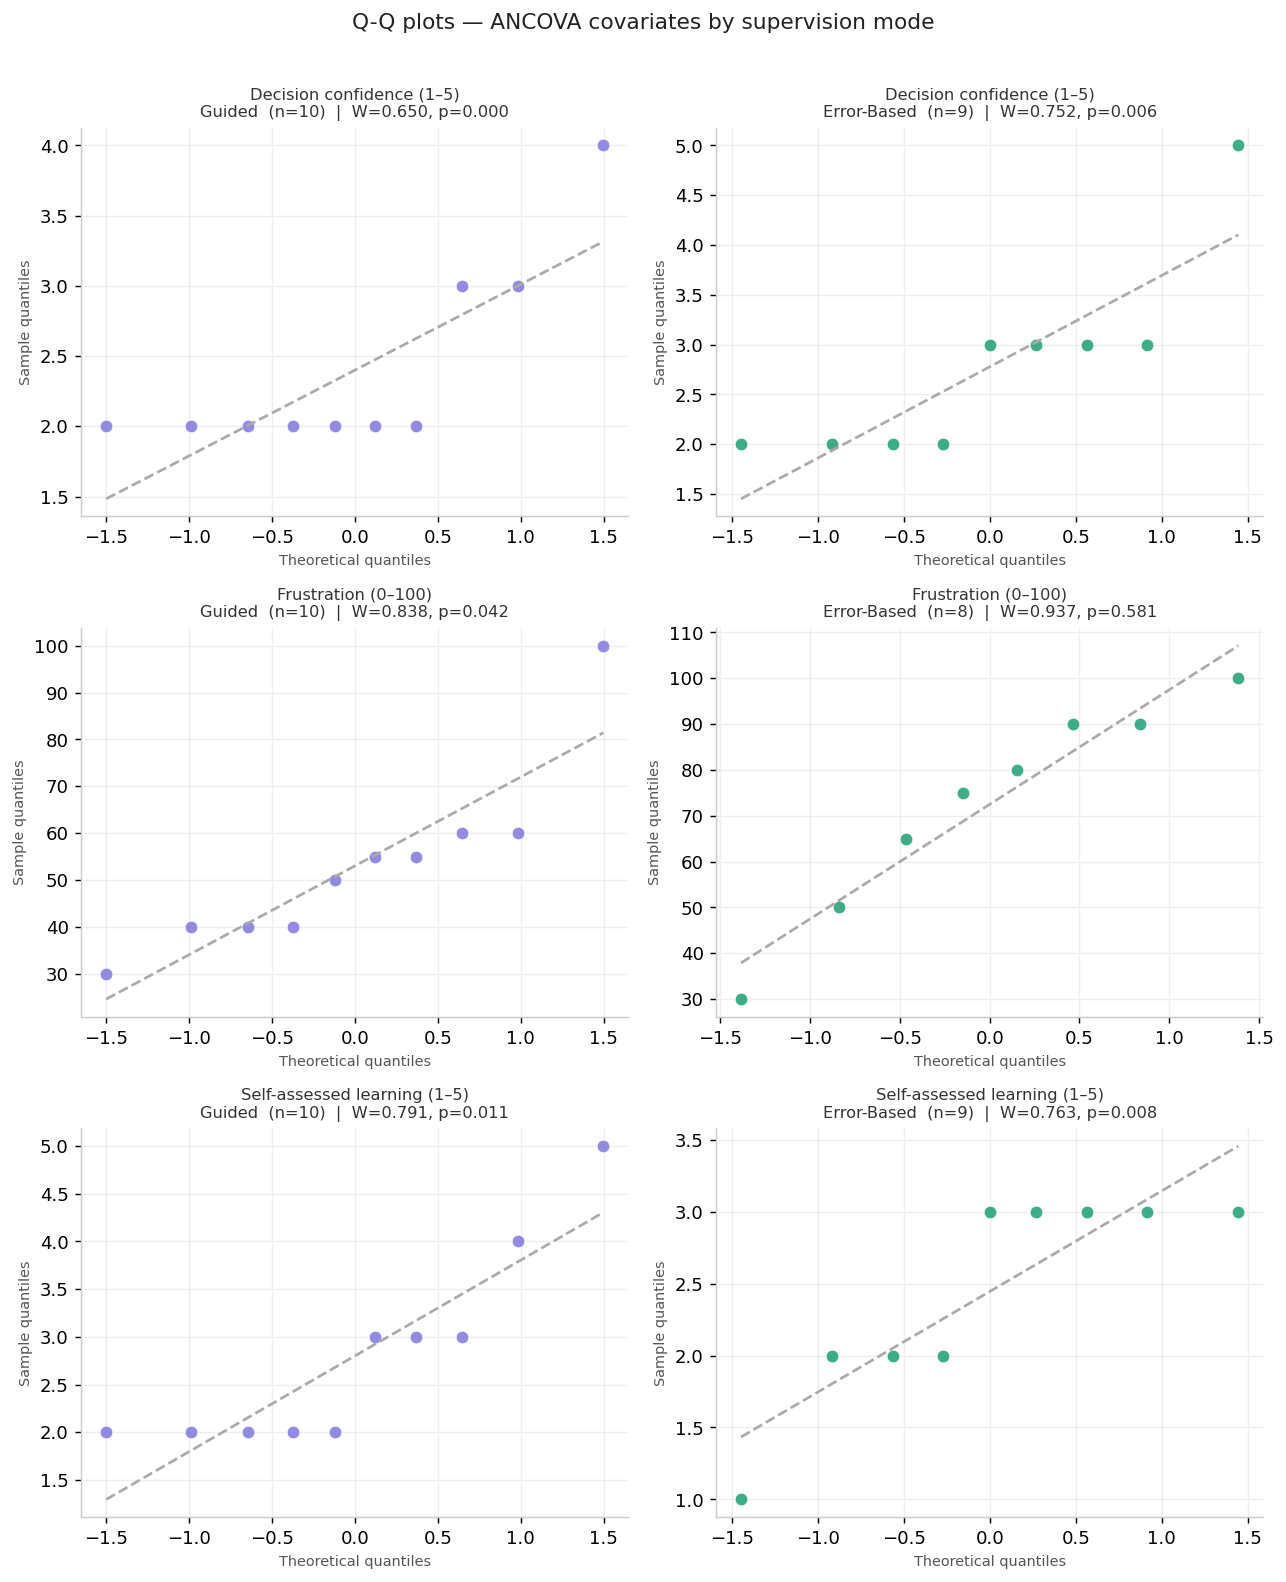

In [35]:
# ════════════════════════════════════════════════════════════════════════════
# SETUP — variables of interest
# ════════════════════════════════════════════════════════════════════════════

OUTCOME   = "test_kendall_tau_total"
COVARS    = {
    "q_q2":             "Decision confidence (1–5)",
    "nasa_frustration":  "Frustration (0–100)",
    "q_q6":             "Self-assessed learning (1–5)",
}


COLORS = {"guided": "#7F77DD", "error_based": "#1D9E75"}
MODES  = ["guided", "error_based"]

# nasa_frustration comes from df_nasa (P026 excluded)
# all other variables from df (n=19)
# we need a merged working frame for ANCOVA
df_ancova = df.copy()
df_ancova["nasa_frustration"] = df_nasa["nasa_frustration"]  # NaN for P026


# ════════════════════════════════════════════════════════════════════════════
# 1. NORMALITY CHECKS — COVARIATES
# ════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("NORMALITY CHECKS — COVARIATES (per supervision mode group)")
print("=" * 65)
print("""
NOTE ON BOUNDED VARIABLES:
  q_q2 and q_q6 are 5-point ordinal scales (discrete, 1–5).
  Shapiro-Wilk is run for completeness but has near-zero power
  at n≈9-10 with only 5 possible values. The Q-Q plot is the
  more informative diagnostic for these variables.
  nasa_frustration (0–100 continuous) is more amenable to
  normality testing but remains bounded.
""")

fig, axes = plt.subplots(len(COVARS), 2, figsize=(10, 4 * len(COVARS)))
fig.patch.set_facecolor("white")

for row_idx, (col, label) in enumerate(COVARS.items()):
    for col_idx, mode in enumerate(MODES):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor("white")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#CCCCCC")

        src = df_nasa if col == "nasa_frustration" else df
        vals = src.loc[src["mode"] == mode, col].dropna()

        # Q-Q plot
        (osm, osr), (slope, intercept, r) = probplot(vals, dist="norm")
        ax.plot(osm, osr, "o", color=COLORS[mode], alpha=0.85,
                markersize=7, markeredgecolor="white", markeredgewidth=0.5)
        ax.plot(osm, slope * np.array(osm) + intercept,
                color="#AAAAAA", lw=1.5, linestyle="--")

        # Shapiro-Wilk
        W, p = shapiro(vals)
        ax.set_title(
            f"{label}\n{mode.replace('_','-').title()}  "
            f"(n={len(vals)})  |  W={W:.3f}, p={p:.3f}",
            fontsize=9, color="#333333", pad=6
        )
        ax.set_xlabel("Theoretical quantiles", fontsize=8, color="#555555")
        ax.set_ylabel("Sample quantiles",      fontsize=8, color="#555555")
        ax.grid(color="#EEEEEE", linewidth=0.8, zorder=0)

        # print to console
        interp = "→ fail to reject normality" if p > .05 else "→ REJECT normality"
        print(f"  {label} | {mode:12s} | n={len(vals)} | "
              f"W={W:.3f}, p={p:.3f}  {interp}")

    print()

fig.suptitle("Q-Q plots — ANCOVA covariates by supervision mode",
             fontsize=12, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("qq_covariates.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

### 3.3. Ancova model comparison

In [ ]:

# ════════════════════════════════════════════════════════════════════════════
# 3. ANCOVA — kendall_tau_total ~ mode [+ covariate]
# ════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("ANCOVA — outcome: test_kendall_tau_total")
print("=" * 65)

def run_ancova(formula, data, label, n_perm=10000):
    model = smf.ols(formula, data=d).fit()
    f_obs = model.fvalue

    # permutation
    f_perm = []
    for _ in range(n_perm):
        d_p = data.copy()
        d_p["mode"] = d_p["mode"].sample(frac=1).values
        try:
            f_perm.append(smf.ols(formula, data=d_p).fit().fvalue)
        except Exception:
            pass
    p_perm = np.mean(np.array(f_perm) >= f_obs)

    print(f"\n  {'─'*55}")
    print(f"  Model: {label}")
    print(f"  n = {len(d)}")
    print(f"  {'─'*55}")
    print(model.summary2().tables[1].to_string())
    print(f"\n  R² = {model.rsquared:.3f}   Adj R² = {model.rsquared_adj:.3f}")
    print(f"  F({model.df_model:.0f}, {model.df_resid:.0f}) = {model.fvalue:.3f},  "
          f"p (parametric) = {model.f_pvalue:.3f}")
    print(f"  p (permutation, {n_perm} perms) = {p_perm:.3f}")
    return model, p_perm


# ── Data frames per model (dropna on relevant columns) ───────────────────────
df_m0 = df_ancova[["test_kendall_tau_total","mode"]].dropna()
df_m1 = df_ancova[["test_kendall_tau_total","mode","q_q2"]].dropna()
df_m2 = df_ancova[["test_kendall_tau_total","mode","nasa_frustration"]].dropna()
df_m3 = df_ancova[["test_kendall_tau_total","mode","q_q6"]].dropna()

m0, p0 = run_ancova("test_kendall_tau_total ~ C(mode)",
                    df_m0, "Baseline: τ ~ mode")
m1, p1 = run_ancova("test_kendall_tau_total ~ C(mode) + q_q2",
                    df_m1, "Model 1:  τ ~ mode + decision confidence")
m2, p2 = run_ancova("test_kendall_tau_total ~ C(mode) + nasa_frustration",
                    df_m2, "Model 2:  τ ~ mode + frustration")
m3, p3 = run_ancova("test_kendall_tau_total ~ C(mode) + q_q6",
                    df_m3, "Model 3:  τ ~ mode + self-assessed learning")


# ── Comparison table ─────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("MODEL COMPARISON — mode coefficient across models")
print("=" * 65)
print(f"{'Model':<45} {'n':>4} {'mode coef':>10} {'p (param)':>10} "
      f"{'p (perm)':>10} {'Adj R²':>8}")
print("-" * 95)

models = [
    ("τ ~ mode",                          df_m0, m0, p0),
    ("τ ~ mode + decision confidence",    df_m1, m1, p1),
    ("τ ~ mode + frustration",            df_m2, m2, p2),
    ("τ ~ mode + self-assessed learning", df_m3, m3, p3),
]

for label, d, m, p_perm in models:
    coef = m.params.get("C(mode)[T.guided]", np.nan)
    p_c  = m.pvalues.get("C(mode)[T.guided]", np.nan)
    print(f"  {label:<43} {len(d):>4} {coef:>10.4f} {p_c:>10.3f} "
          f"{p_perm:>10.3f} {m.rsquared_adj:>8.3f}")


# ── Residual Q-Q plots for each fitted model ──────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
fig.patch.set_facecolor("white")

for ax, (label, _, m, _) in zip(axes, models):
    resid = m.resid
    (osm, osr), (slope, intercept, r) = probplot(resid, dist="norm")
    ax.plot(osm, osr, "o", color="#378ADD", alpha=0.8,
            markersize=7, markeredgecolor="white", markeredgewidth=0.5)
    ax.plot(osm, slope * np.array(osm) + intercept,
            color="#AAAAAA", lw=1.5, linestyle="--")
    W, p = shapiro(resid)
    ax.set_title(f"{label}\nResiduals  W={W:.3f}, p={p:.3f}",
                 fontsize=8, color="#333333", pad=6)
    ax.set_xlabel("Theoretical quantiles", fontsize=8, color="#555555")
    ax.set_ylabel("Residuals",             fontsize=8, color="#555555")
    ax.set_facecolor("white")
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#CCCCCC")
    ax.grid(color="#EEEEEE", linewidth=0.8, zorder=0)

fig.suptitle("Q-Q plots of ANCOVA residuals — normality of residuals check",
             fontsize=11, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("qq_ancova_residuals.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

ANCOVA — outcome: test_kendall_tau_total


NameError: name 'd' is not defined